# **Fundamentos de Aprendizaje por Refuerzo**
## **Q-Learning Algorithm**


In [1]:
pip install gymnasium

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
pip install pygame

  Using cached pygame-2.6.1.tar.gz (14.8 MB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [112 lines of output]
      Skipping Cython compilation
      
      
      WARNING, No "Setup" File Exists, Running "buildconfig/config.py"
      Using WINDOWS configuration...
      
      Making dir :prebuilt_downloads:
      Downloading... https://www.libsdl.org/release/SDL2-devel-2.28.4-VC.zip 25ef9d201ce3fd5f976c37dddedac36bd173975c
      Unzipping :prebuilt_downloads\SDL2-devel-2.28.4-VC.zip:
      Downloading... https://www.libsdl.org/projects/SDL_image/release/SDL2_image-devel-2.0.5-VC.zip 137f86474691f4e12e76e07d58d5920c8d844d5b
      Unzipping :prebuilt_downloads\SDL2_image-devel-2.0.5-VC.zip:
      Downloading... https://github.com/libsdl-org/SDL_ttf/releases/download/release-2.20.1/SDL2_ttf-devel-2.20.1-VC.zip 371606aceba450384428fd2852f73d2f6290b136
      Unzipping :prebuilt_downloads\SDL2_ttf-devel-2.20.1-VC.zip:
      Downloading... https://g

In [3]:
pip install imageio

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


### **Liberías**

In [4]:
import numpy as np
import gymnasium as gym
import random
from collections import deque
import matplotlib.pyplot as plt
import imageio
from IPython.display import Image

## **Visualización gráfica del entorno**

Entorno obtenido de: https://gymnasium.farama.org/environments/toy_text/cliff_walking/

## **Funcionamiento del entorno**

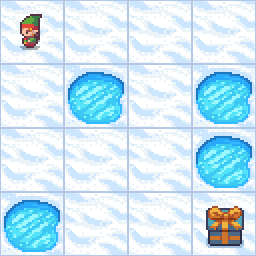

In [5]:
env = gym.make('FrozenLake-v1', render_mode="rgb_array")
state, _ = env.reset()
done = False
frames = []
for i in range(20):
    action = random.choice([0,1,2,3])  # Elegir una acción random
    next_state, reward ,done, _, _ = env.step(action)
    frame = env.render()
    frames.append(frame)
    state = next_state
env.close()
imageio.mimsave('FrozenLake_env.gif', frames, fps=3)
Image(filename='FrozenLake_env.gif')

## **Crear y observar el ambiente (estados y acciones)**

In [6]:
env = gym.make('FrozenLake-v1', render_mode="rgb_array")
num_states = env.observation_space.n
num_actions = env.action_space.n
print("Número de estados:", num_states)
print("Número de acciones:", num_actions)

Número de estados: 16
Número de acciones: 4


## **Q-Learning Implementation**

**Epsilon-Greedy Policy**

\begin{align}
a_t =
        \begin{cases}
        \text{random action} & \quad\text{with probability  }\epsilon \\
        \displaystyle\text{arg}\max_a{Q(s_t,:)}&\quad\text{with probability  }   1-\epsilon
        \end{cases}
\end{align}


**Q-learning Algorithm**


<img src="https://raw.githubusercontent.com/cdavid2804/test-1/main/Q_learning_Algorithm.png" alt="QL_Algorithm" width="600"/>

In [7]:
alpha = 0.7 # taza de aprendizaje
gamma = 0.995 # factor de descuento
epsilon = 0.1
num_episodes = 1000
episode_reward = deque(maxlen=num_episodes)

Q = np.zeros((num_states, num_actions))
np.random.seed(0)

# Política
def epsilon_greedy(state,epsilon):
  if np.random.rand() < epsilon:
    action = np.random.randint(num_actions)
  else:
    action = np.argmax(Q[state,:])
  return action

def reward_function(state, next_state ,action):
  if next_state == 15:
    return 10000
  else:
    return -20
  if next_state == 5 or 7 or 11 or 12 or 0:
    return -500
  else:
    return 20
  if state == next_state:
    return -500
  else:
    return 10

# Entrenamiento
for episode in range(num_episodes):
  state,_ = env.reset()
  done = False
  total_reward = 0
  steps = 0
  while not done:
    action = epsilon_greedy(state, epsilon)
    next_state, _, done,_, _ = env.step(action)
    reward = reward_function(state,next_state, action)
    Q[state,action] = Q[state,action] + alpha*(reward + gamma*np.max(Q[next_state,:]) - Q[state,action])
    total_reward += reward
    state = next_state
    steps += 1
  episode_reward.append((episode, total_reward))
  print(f"Episodio:{episode}  Recompensa total:{total_reward}  Pasos por episodio:{steps}")

Episodio:0  Recompensa total:-520  Pasos por episodio:26
Episodio:1  Recompensa total:-100  Pasos por episodio:5
Episodio:2  Recompensa total:-140  Pasos por episodio:7
Episodio:3  Recompensa total:-60  Pasos por episodio:3
Episodio:4  Recompensa total:-40  Pasos por episodio:2
Episodio:5  Recompensa total:-140  Pasos por episodio:7
Episodio:6  Recompensa total:-320  Pasos por episodio:16
Episodio:7  Recompensa total:-80  Pasos por episodio:4
Episodio:8  Recompensa total:-120  Pasos por episodio:6
Episodio:9  Recompensa total:-160  Pasos por episodio:8
Episodio:10  Recompensa total:-240  Pasos por episodio:12
Episodio:11  Recompensa total:-240  Pasos por episodio:12
Episodio:12  Recompensa total:-40  Pasos por episodio:2
Episodio:13  Recompensa total:-200  Pasos por episodio:10
Episodio:14  Recompensa total:-140  Pasos por episodio:7
Episodio:15  Recompensa total:-120  Pasos por episodio:6
Episodio:16  Recompensa total:-80  Pasos por episodio:4
Episodio:17  Recompensa total:-80  Pasos 

## **Gráfica de la recompensa total acumulada y recompensa promedio**

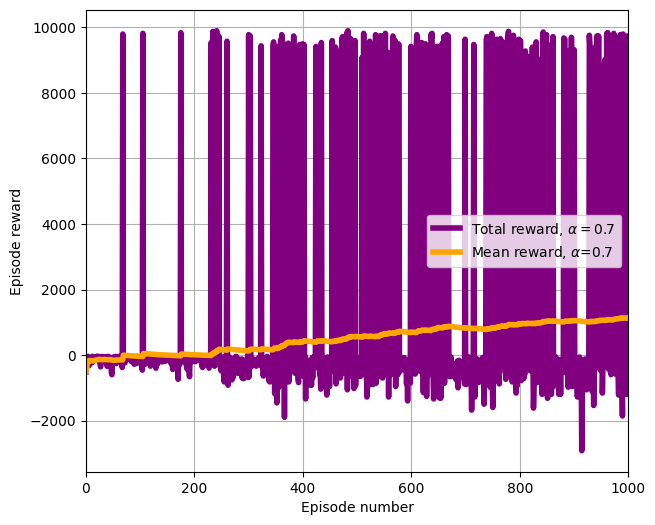

In [8]:
episodeReward = np.array(episode_reward)
episodes = episodeReward[:,0]
# Total rewards
rewards = episodeReward[:,1]
# Mean rewards
meanRewards = np.zeros(len(episodes))

for i in range(len(episodes)):
    if i == 0:
        meanRewards[0] = rewards[0]
    else:
        meanRewards[i] = np.mean(rewards[:i])
plt.figure(figsize=(7, 6))
plt.plot(episodes, rewards, label=r"Total reward, $\alpha=$"+str(alpha), linewidth=4, color='purple')
plt.plot(episodes, meanRewards, label=r"Mean reward, $\alpha$="+str(alpha), linewidth=4, color='orange')
plt.xlabel("Episode number")
plt.ylabel("Episode reward")
plt.xlim(0, num_episodes)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.legend(fontsize=10)
plt.grid()
plt.legend()
plt.show()

## **Probar la política entrenada**

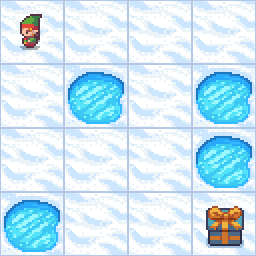

In [9]:
env = gym.make('FrozenLake-v1', render_mode="rgb_array")
state, _ = env.reset()
done = False
frames = []
for i in range(30):
    action = np.argmax(Q[state,:])  # Elegir la mejor acción según la tabla Q
    next_state, _, done, _, _ = env.step(action)
    frame = env.render()
    frames.append(frame)
    state = next_state
env.close()
imageio.mimsave('FrozenLake_test.gif', frames, fps=3)
Image(filename='FrozenLake_test.gif')